<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/02_deep_learning_foundations/11_first_neural_network_with_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=float)

y = np.array([
    [0],
    [0],
    [0],
    [1]
], dtype=float)

print("Features:")
print(X)

print("\nLabels:")
print(y)

Features:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Labels:
[[0.]
 [0.]
 [0.]
 [1.]]


In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        4,
        activation="relu",
        input_shape=(2,)
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [6]:
history = model.fit(

    X,

    y,

    epochs=100,

    batch_size=4,

    verbose=1

)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.7504
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5000 - loss: 0.7491
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5000 - loss: 0.7478
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5000 - loss: 0.7465
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5000 - loss: 0.7452
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5000 - loss: 0.7439
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5000 - loss: 0.7426
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5000 - loss: 0.7414
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5000 - loss: 0.7401
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5000 - loss: 0.7388
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5000 - loss: 0.7376
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5000 - loss

In [7]:
loss, accuracy = model.evaluate(X, y)

print("Loss:", loss)

print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.5000 - loss: 0.6404
Loss: 0.640430212020874
Accuracy: 0.5


In [8]:
predictions = model.predict(X)

print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
[[0.46029085]
 [0.57014894]
 [0.5029821 ]
 [0.6692817 ]]


In [9]:
predicted_classes = (predictions >= 0.5).astype(int)

print(predicted_classes)

[[0]
 [1]
 [1]
 [1]]


In [10]:
results = pd.DataFrame({

    "Input 1": X[:,0].astype(int),

    "Input 2": X[:,1].astype(int),

    "Actual": y.flatten().astype(int),

    "Probability": predictions.flatten(),

    "Predicted": predicted_classes.flatten()

})

results

,Input 1,Input 2,Actual,Probability,Predicted
0,0,0,0,0.460291,0
1,0,1,0,0.570149,1
2,1,0,0,0.502982,1
3,1,1,1,0.669282,1


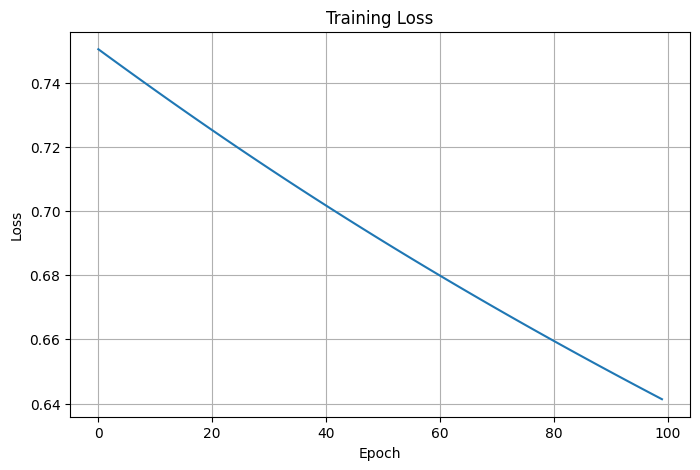

In [11]:
plt.figure(figsize=(8,5))

plt.plot(

    history.history["loss"]

)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.show()

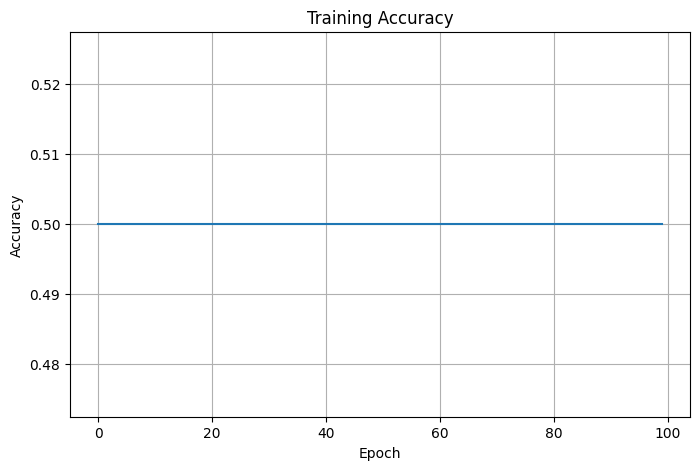

In [12]:
plt.figure(figsize=(8,5))

plt.plot(

    history.history["accuracy"]

)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid()

plt.show()

In [13]:
weights = model.get_weights()

for weight in weights:

    print(weight)

[[ 0.71198064 -0.09695973  1.0907841   0.11398719]
 [ 0.6040678   0.40646347 -1.0855174  -0.5848198 ]]
[-0.09227388 -0.08378132  0.11116658  0.10410625]
[[ 0.64107454]
 [ 0.15575394]
 [-0.16190757]
 [-0.43489063]]
[-0.09589826]


In [14]:
history.history

{'accuracy': [0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5],
 'loss': [0.7503736019134521,
  0.7490754723548889,
  0.7477838397026062,
  0.746494710445404,
  0.7452085614204407,
  0.7439258694648743,
  0.7426468133926392,
  0.7413715124130249,
  0.7401001453399658,
  0.7388327121734619,
  0.7375693917274475,
  0.7363101243972778,
  0.735055029392

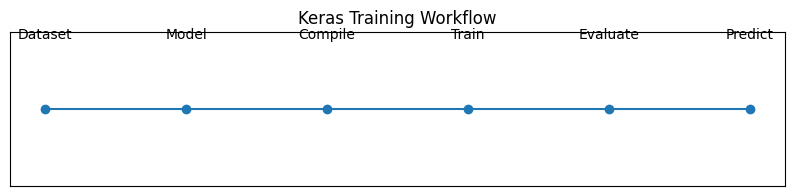

In [15]:
steps = [

    "Dataset",

    "Model",

    "Compile",

    "Train",

    "Evaluate",

    "Predict"

]

plt.figure(figsize=(10,2))

plt.plot(

    range(len(steps)),

    [1]*len(steps),

    marker="o"

)

for i, step in enumerate(steps):

    plt.text(

        i,

        1.05,

        step,

        ha="center"

    )

plt.xticks([])

plt.yticks([])

plt.title("Keras Training Workflow")

plt.show()

In [16]:
summary = pd.DataFrame({

    "Step":[

        "Create Model",

        "Compile",

        "Train",

        "Evaluate",

        "Predict"

    ],

    "Purpose":[

        "Define Architecture",

        "Configure Training",

        "Learn from Data",

        "Measure Performance",

        "Generate Predictions"

    ]

})

summary

,Step,Purpose
0,Create Model,Define Architecture
1,Compile,Configure Training
2,Train,Learn from Data
3,Evaluate,Measure Performance
4,Predict,Generate Predictions
